In [1]:
import numpy as np
import matplotlib.pyplot as plt

from few.waveform import GenerateEMRIWaveform
from few.utils.constants import MTSUN_SI
from few.utils.utility import get_p_at_t
from few.utils.geodesic import get_fundamental_frequencies
from few.utils.fdutils import GetFDWaveformFromFD, GetFDWaveformFromTD
from few.trajectory.inspiral import EMRIInspiral
from few.utils.geodesic import get_separatrix
from few.trajectory.ode.flux import KerrEccEqFlux, KerrEccEqFlux_nex
from few.amplitude.ampinterp2d import AmpInterpKerrEccEq_nex , AmpInterpKerrEccEq
from few.utils.mappings.kerrecceq import p_of_u_nex, DELTAPMIN_REGIONC_amp

from scipy.interpolate import CubicSpline
from few import get_file_manager
from few.utils.ylm import GetYlms
from few.utils.modeselector import ModeSelector
import few
# tune few configuration
cfg_set = few.get_config_setter(reset=True)

cfg_set.set_log_level("info");


plt.rcParams.update({
    "font.family": "STIXGeneral",
    "mathtext.fontset": "stix",
    "font.size": 12,
})

from cycler import cycler

plt.rcParams['axes.prop_cycle'] = cycler(color=[
    "#373E8E",  # black
    "#b4af1f",  # blue
    '#ff7f0e',  # orange
    '#2ca02c',  # green
    '#d62728',  # red
    '#9467bd',  # purple
    '#8c564b',  # brown
])

from mpl_toolkits.axes_grid1 import make_axes_locatable

import warnings

warnings.filterwarnings("ignore", category=RuntimeWarning)

## Code adapted from the "Modeselect" example notebook

In [2]:
traj_few = EMRIInspiral(func=KerrEccEqFlux)
traj_nex = EMRIInspiral(func=KerrEccEqFlux_nex)
amp_module_few = AmpInterpKerrEccEq()
amp_module_nex = AmpInterpKerrEccEq_nex()
ylm_gen = GetYlms()

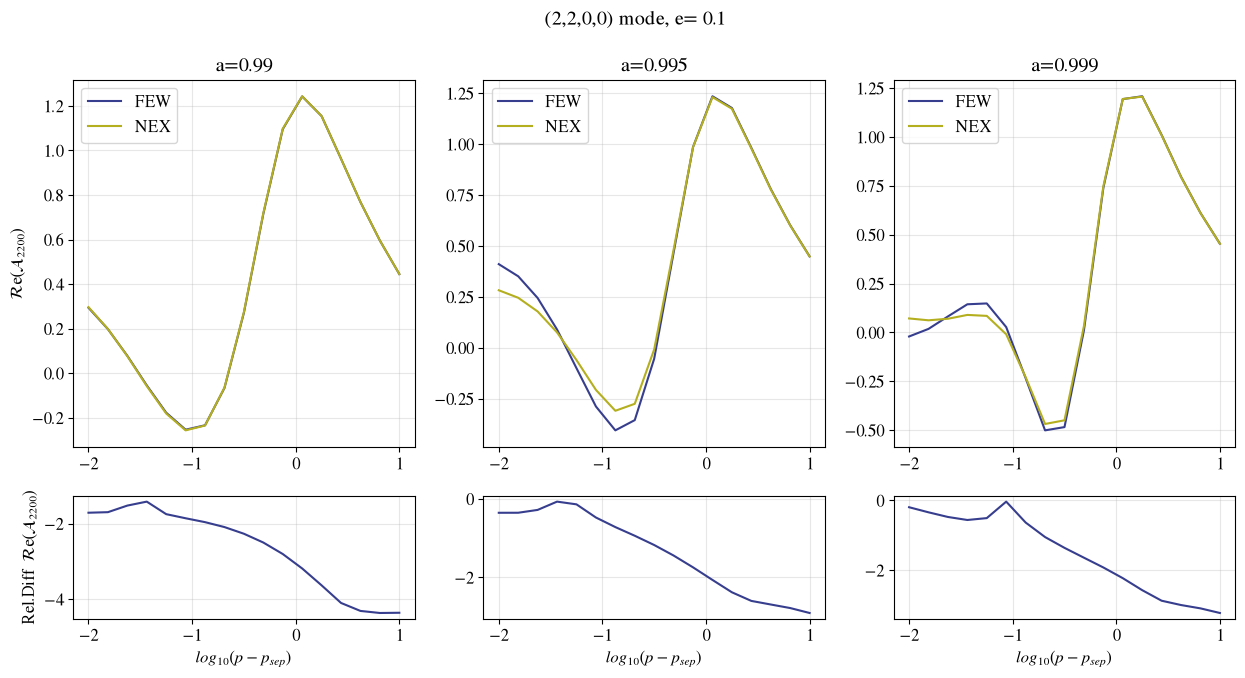

In [3]:
a_vals = [0.99,0.995,0.999]
e_val = 0.1
x=1
u = np.linspace(0,1,17)

fig,axs = plt.subplots(2,len(a_vals),figsize=(5*len(a_vals),7),gridspec_kw={"height_ratios": [3, 1]})

for i, a_val in enumerate(a_vals):

    plso = get_separatrix(a_val,e_val,x)
    p = p_of_u_nex(u,plso,DELTAPMIN_REGIONC_amp)
    a = np.ones_like(p)*a_val
    e = np.ones_like(p)*e_val
    xI = np.ones_like(p)

    specific_modes = [(2,2,0,0)]

    amp_mode_nex, amp_mode_few = amp_module_nex(a, p, e, xI , specific_modes=specific_modes)[(2,2,0,0)] , amp_module_few(a, p, e, xI , specific_modes=specific_modes)[(2,2,0,0)]

    axs[0,i].plot(np.log10(p-plso),amp_mode_few, "-",label="FEW")
    axs[0,i].plot(np.log10(p-plso),amp_mode_nex, "-",label="NEX")

    axs[0,i].legend()
    axs[0,i].grid(alpha=0.3)
   # axs[0,i].set_xlabel(r"$log_{10}(p-p_{sep})$")
    axs[0,i].set_title(f"a={a_val}")
    axs[0,0].set_ylabel(r"$\mathcal{Re(A_{2200})}$")


    axs[1,i].plot(np.log10(p-plso),np.log10(np.abs(amp_mode_few-amp_mode_nex)/np.abs(amp_mode_nex)), "-")
    axs[1,i].grid(alpha=0.3)
    axs[1,i].set_xlabel(r"$log_{10}(p-p_{sep})$")
    axs[1,0].set_ylabel(r"Rel.Diff  $\mathcal{ Re(A_{2200})}$")

    plt.suptitle(rf"(2,2,0,0) mode, e= {e_val}")

    #plt.xlim(plso,2)
    plt.savefig(f"Compare_LMN220_mode_e0={e_val}.png", dpi=300, bbox_inches="tight")

In [6]:

0.9999982217   1.0432708450  0.00  1.0


SyntaxError: invalid syntax (3087202151.py, line 1)

New p0:  1.4707297231431777


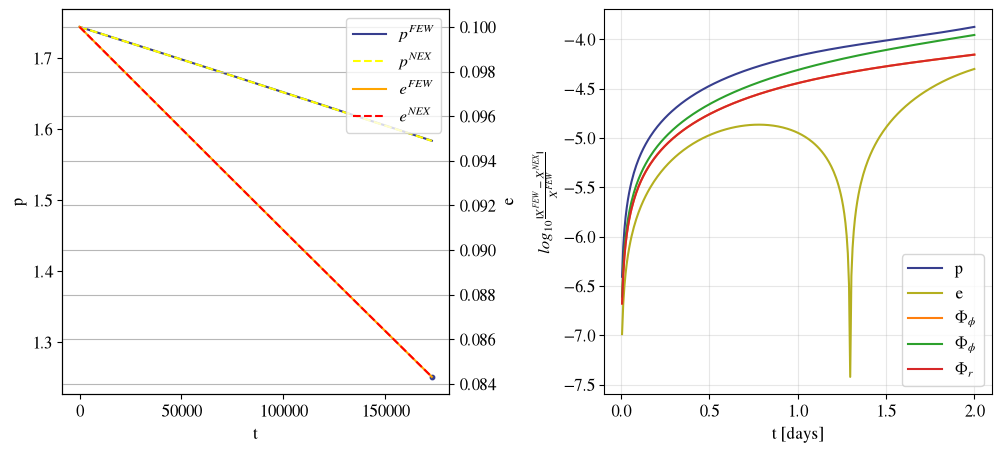

In [46]:

# parameters
m1 = 1e6
m2 = 10
a = 0.999
p0 = 1.7
e0 = 0.1
theta = np.pi / 3.0
phi = np.pi / 2.0

Tobs= 2/365

p0 = get_p_at_t(
    traj_few,
    Tobs ,
    [m1, m2, a, e0, 1.0],       # list of trajectory arguments, with p removed
    index_of_p=3,               # index where to insert the new p values in the above traj_args list when traj_module is called 
    index_of_a=2,               # index of a in the list of trajectory arguments when calling traj_module
    index_of_e=4,               # etc...
    index_of_x=5,
    traj_kwargs={},
    xtol=2e-12,                 # absolute tolerance for the brentq root finder
    rtol=8.881784197001252e-16, # relative tolerance for the brentq root finder
    bounds=None,
)  +0.05                 # +0.05 to ensure the *300 linspace is saturated, and both arrays are the same length
print("New p0: ", p0)
p0 = 1.7439798472121146

t_max =Tobs
t_new = np.linspace(0,t_max*365*3600*24,300)


t, p, e, x, Phi_phi, Phi_theta, Phi_r = traj_few(m1, m2, a, p0, e0, 1.0, T=t_max, new_t = t_new, fix_t=True, upsample = True)
t_nex, p_nex, e_nex, x_nex, Phi_phi_nex, Phi_theta_nex, Phi_r_nex = traj_nex(m1, m2, a, p0, e0, 1.0,T=t_max, new_t = t_new, fix_t=True, upsample = True)

fig,axs = plt.subplots(1,2,figsize=(12,5))

axs[1].plot(t/60/60/24,np.log10(np.abs(p-p_nex)/p),label = "p")
axs[1].plot(t/60/60/24,np.log10(np.abs(e-e_nex)/e),label = "e")
axs[1].plot(t/60/60/24,np.log10(np.abs(Phi_phi-Phi_phi_nex)/Phi_phi),label = r"$\Phi_{\phi}$")
axs[1].plot(t/60/60/24,np.log10(np.abs(Phi_r-Phi_r_nex)/Phi_r),label = r"$\Phi_{\phi}$")
axs[1].plot(t/60/60/24,np.log10(np.abs(Phi_phi-Phi_phi_nex)/Phi_phi),label = r"$\Phi_{r}$")
axs[1].legend()

axs[1].grid(alpha=0.3)
axs[1].set_xlabel("t [days]")
axs[1].set_ylabel(r"$log_{10}\frac{|X^{FEW}-X^{NEX}|}{X^{FEW}}$")

line1, = axs[0].plot(t, p ,label=r"$p^{FEW}$")
line1a, = axs[0].plot(t, p_nex ,"--", color = "yellow", label=r"$p^{NEX}$")
axs[0].set_xlabel("t")
axs[0].set_ylabel("p")
axs[0].scatter(t[-1],get_separatrix(a,e[-1],1)+2*DELTAPMIN_REGIONC_amp,s=10)

# Second dataset (right axis)
ax2 = axs[0].twinx()
line2, = ax2.plot(t, e,color = "orange", label=r"$e^{FEW}$")
line2a, = ax2.plot(t, e_nex, "--" ,color = "red", label=r"$e^{NEX}$")
ax2.set_ylabel("e")
ax2.grid(alpha=0.9)






plt.subplots_adjust(wspace=0.4,hspace=0.3)


ax2.legend(handles=[line1,line1a ,line2,line2a], loc="best")


In [47]:
print(len(t))

300


In [48]:

# select modes

mode_selector_few = ModeSelector(
    amp_module_few,
    ylm_generator=ylm_gen,  # optional, this is the default choice
    force_backend="cpu"
)
mode_selector_nex = ModeSelector(
    amp_module_nex,
    ylm_generator=ylm_gen,  # optional, this is the default choice
    force_backend="cpu"
)

mode_selection_threshold = 1e-4  # target mismatch between reduced and full mode content waveforms

for mode_selector in [mode_selector_few,mode_selector_nex]:

    (teuk_modes_r, ylms_r, ls_r, ms_r, ks_r, ns_r) = mode_selector(
        t,
        a, 
        p, 
        e, 
        x, 
        theta, 
        phi, 
        mode_selection_threshold=mode_selection_threshold  # this can also be provided to ModeSelector() on instantiation
    )

    (teuk_modes, ylms, ls, ms, ks, ns) = mode_selector(
        t,
        a, 
        p, 
        e, 
        x, 
        theta, 
        phi, 
        mode_selection = "all",  # this can also be provided to ModeSelector() on instantiation
    )

    print(
        "FEW: We reduced the mode content from {} modes to {} modes, with a mode_selection_threshold of {}".format(
            teuk_modes.shape[1], teuk_modes_r.shape[1], mode_selection_threshold
        )
    )


FEW: We reduced the mode content from 6993 modes to 146 modes, with a mode_selection_threshold of 0.0001
FEW: We reduced the mode content from 18013 modes to 160 modes, with a mode_selection_threshold of 0.0001


In [49]:
teuk_modes_r

array([[ 0.00420049+0.01136585j, -0.01129664-0.05057931j,
        -0.00010491-0.0070958j , ...,  0.00368988+0.00077082j,
         0.005025  +0.00569829j,  0.00132958+0.0067524j ],
       [ 0.00419769+0.01136454j, -0.01127741-0.05055501j,
        -0.00010269-0.00708813j, ...,  0.00371837+0.00079626j,
         0.00502646+0.00572381j,  0.00131914+0.00675482j],
       [ 0.00419488+0.01136323j, -0.01125817-0.05053068j,
        -0.00010048-0.00708047j, ...,  0.00374674+0.0008217j ,
         0.00502769+0.0057491j ,  0.00130863+0.00675691j],
       ...,
       [ 0.00310203+0.01085057j, -0.00529021-0.04174849j,
         0.00041628-0.00500369j, ...,  0.00056897+0.00300672j,
        -0.00283149-0.00089825j, -0.00111617-0.00416504j],
       [ 0.00309736+0.01084831j, -0.00526957-0.04171285j,
         0.00041759-0.00499746j, ...,  0.00051654+0.0029803j ,
        -0.0028641 -0.00095881j, -0.00111264-0.00420875j],
       [ 0.00309268+0.01084606j, -0.00524893-0.04167716j,
         0.00041889-0.00499123

In [50]:
mode_selection_threshold=1e-1
(teuk_modes_r, ylms_r, ls_r, ms_r, ks_r, ns_r) = mode_selector_few(
    t,
    a, 
    p, 
    e, 
    x, 
    theta, 
    phi, 
    mode_selection_threshold=mode_selection_threshold  # this can also be provided to ModeSelector() on instantiation
)


(teuk_modes_r_nex, ylms_r_nex, ls_r_nex, ms_r_nex, ks_r_nex, ns_r_nex) = mode_selector_nex(
    t,
    a, 
    p, 
    e, 
    x, 
    theta, 
    phi, 
    mode_selection_threshold=mode_selection_threshold  # this can also be provided to ModeSelector() on instantiation
)
print(
    "FEW: We reduced the mode content from {} modes to {} modes, with a mode_selection_threshold of {}".format(
        teuk_modes.shape[1], teuk_modes_r.shape[1], mode_selection_threshold
    )
)

FEW: We reduced the mode content from 18013 modes to 6 modes, with a mode_selection_threshold of 0.1


### First handle the mode indeces

In [51]:
p

array([1.74397985, 1.74345448, 1.74292903, 1.74240349, 1.74187787,
       1.74135216, 1.74082637, 1.74030049, 1.73977453, 1.73924848,
       1.73872235, 1.73819614, 1.73766984, 1.73714345, 1.73661699,
       1.73609044, 1.7355638 , 1.73503708, 1.73451028, 1.7339834 ,
       1.73345643, 1.73292938, 1.73240225, 1.73187503, 1.73134773,
       1.73082035, 1.73029289, 1.72976534, 1.72923772, 1.72871001,
       1.72818221, 1.72765434, 1.72712638, 1.72659835, 1.72607023,
       1.72554203, 1.72501375, 1.72448539, 1.72395695, 1.72342842,
       1.72289982, 1.72237113, 1.72184237, 1.72131352, 1.7207846 ,
       1.72025559, 1.71972651, 1.71919734, 1.7186681 , 1.71813878,
       1.71760937, 1.71707989, 1.71655033, 1.71602069, 1.71549097,
       1.71496117, 1.7144313 , 1.71390134, 1.71337131, 1.7128412 ,
       1.71231101, 1.71178074, 1.7112504 , 1.71071998, 1.71018948,
       1.7096589 , 1.70912824, 1.70859751, 1.70806671, 1.70753582,
       1.70700486, 1.70647382, 1.70594271, 1.70541152, 1.70488

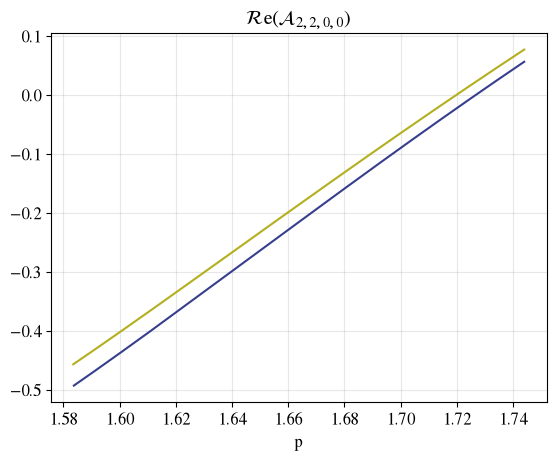

In [52]:
mode = [(2,2,0,0)]

mode_few = np.real(amp_module_few(a, p, e, x , specific_modes=mode)[(2,2,0,0)])
mode_nex = np.real(amp_module_nex(a, p_nex, e_nex, x , specific_modes=mode)[(2,2,0,0)])
plt.title(r"$\mathcal{Re (A}_{2,2,0,0})$")

plt.plot(p,mode_few,label = "FEW")
plt.plot(p_nex,mode_nex,label = "NEX")
plt.xlabel("p")
plt.grid(alpha=0.3)

In [53]:
mode_nex

array([ 7.71460197e-02,  7.54975644e-02,  7.38475475e-02,  7.21959750e-02,
        7.05428532e-02,  6.88881883e-02,  6.72319868e-02,  6.55742550e-02,
        6.39149994e-02,  6.22542265e-02,  6.05919429e-02,  5.89281553e-02,
        5.72628703e-02,  5.55960949e-02,  5.39278357e-02,  5.22580998e-02,
        5.05868940e-02,  4.89142255e-02,  4.72401014e-02,  4.55645288e-02,
        4.38875149e-02,  4.22090671e-02,  4.05291928e-02,  3.88478994e-02,
        3.71651944e-02,  3.54810853e-02,  3.37955799e-02,  3.21086859e-02,
        3.04204110e-02,  2.87307632e-02,  2.70397488e-02,  2.53473714e-02,
        2.36536339e-02,  2.19585396e-02,  2.02620916e-02,  1.85642931e-02,
        1.68651475e-02,  1.51646579e-02,  1.34628277e-02,  1.17596603e-02,
        1.00551590e-02,  8.34932730e-03,  6.64216860e-03,  4.93368642e-03,
        3.22388430e-03,  1.51276580e-03, -1.99665476e-04, -1.91340587e-03,
       -3.62845172e-03, -5.34479929e-03, -7.06244484e-03, -8.78138457e-03,
       -1.05016147e-02, -

In [54]:
modes_nex_reduced = [
    (int(l), int(m), int(k), int(n))
    for l, m, k, n in zip(ls_r_nex, ms_r_nex, ks_r_nex, ns_r_nex)
]

modes_few_reduced = [
    (int(l), int(m), int(k), int(n))
    for l, m, k, n in zip(ls_r, ms_r, ks_r, ns_r)
]
shared_modes = list(set(modes_nex_reduced) & set(modes_few_reduced))

print(len(shared_modes))

shared_modes_sum_nex = np.zeros_like(p)
shared_modes_sum = np.zeros_like(p)

for mode in shared_modes:
    shared_modes_sum += np.real(amp_module_few(a, p, e, x , specific_modes=[mode])[mode])
    shared_modes_sum_nex += np.real(amp_module_nex(a, p, e, x , specific_modes=[mode])[mode])

6


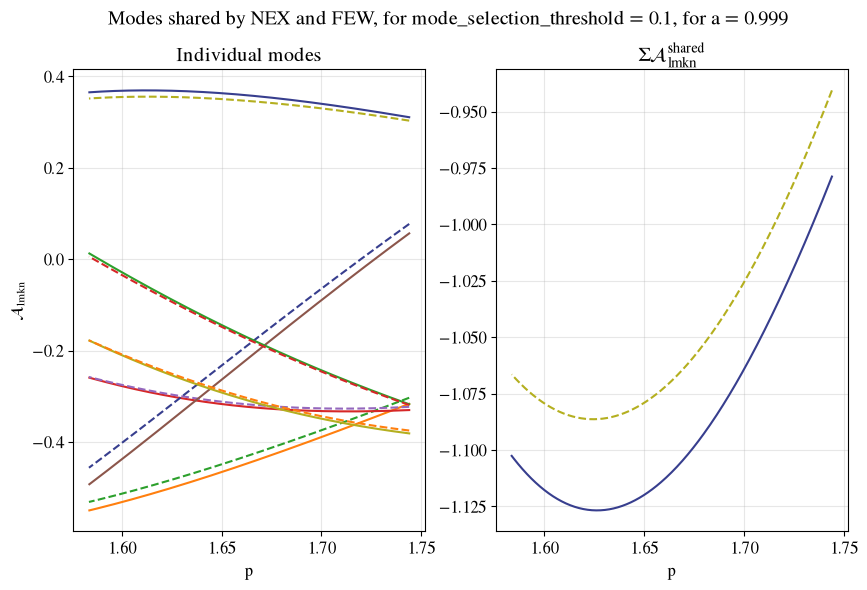

In [56]:
fig, axs = plt.subplots(1,2,figsize=(10,6))

for mode in shared_modes:
    axs[0].plot(p,amp_module_few(a, p, e, x , specific_modes=[mode])[mode],label=f"{mode}")
    axs[0].plot(p_nex,amp_module_nex(a, p_nex, e_nex, x , specific_modes=[mode])[mode] , "--")

axs[1].plot(p,shared_modes_sum)
axs[1].plot(p,shared_modes_sum_nex,"--")

axs[1].set_title(r"$\Sigma \mathcal{A_{lmkn}^{shared}}$")

axs[0].set_title("Individual modes")

#axs[0].legend(fontsize=10,loc="upper right")
axs[0].grid(alpha=0.3)
axs[1].grid(alpha=0.3)
axs[0].set_xlabel("p")
axs[1].set_xlabel("p")
axs[0].set_ylabel(r"$\mathcal{A_{lmkn}}$")

plt.suptitle(f"Modes shared by NEX and FEW, for mode_selection_threshold = 0.1, for a = {a}")

plt.savefig(f"Compare_shared_modes_e0={e_val}_a={a}_fixedp.png", dpi=300, bbox_inches="tight")

In [39]:
shared_modes_sum_nex = np.zeros_like(p)
shared_modes_sum = np.zeros_like(p)

for mode in shared_modes:
    shared_modes_sum += np.real(amp_module_few(a, p, e, x , specific_modes=[mode])[mode])
    shared_modes_sum_nex += np.real(amp_module_nex(a, p, e, x , specific_modes=[mode])[mode])

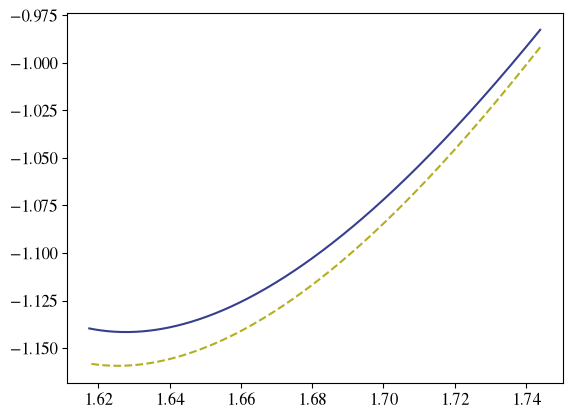

In [40]:
plt.plot(p,shared_modes_sum)
plt.plot(p,shared_modes_sum_nex,"--")

In [41]:
amp_few = np.sum(teuk_modes_r,axis=1)
amp_nex = np.sum(teuk_modes_r_nex,axis=1)


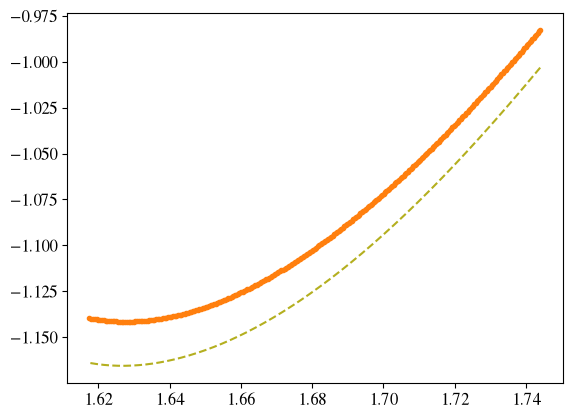

In [61]:
plt.plot(p,np.real(amp_few))
plt.plot(p_nex,np.real(amp_nex),"--")

plt.plot(p,shared_modes_sum,".")

NameError: name 'amp_few' is not defined

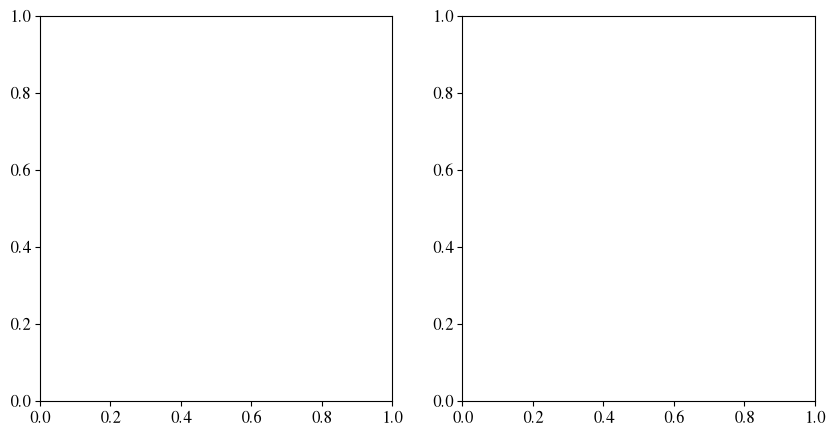

In [37]:
fig, axs = plt.subplots(1,2,figsize=(10,5))

axs[0].plot(p,np.real(amp_few),label="total few")
axs[0].plot(p_nex,np.real(amp_nex),"--", label = "total nex")

axs[0].plot(p,shared_modes_sum,".")
axs[0].plot(p,shared_modes_sum_nex,".")

axs[1].plot(p,shared_modes_sum)
axs[1].plot(p,shared_modes_sum_nex,"--")

axs[1].set_title(r"$\Sigma \mathcal{A_{lmkn}^{shared}}$")

axs[0].legend(fontsize=10,loc="upper right")
axs[0].grid(alpha=0.3)
axs[1].grid(alpha=0.3)

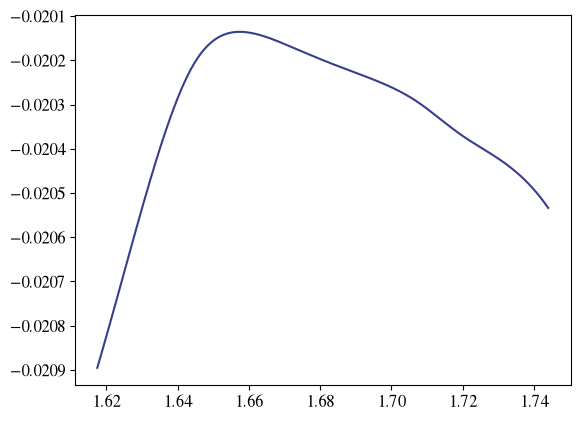

In [63]:
plt.plot(p, np.abs(np.real(amp_nex)-np.real(amp_few))/np.real(amp_nex))